# WEEK 2 TASK — Deep EDA, Feature Engineering & Baseline Modeling
# Steel Industry Energy Consumption Dataset

0. SETUP & DATA UPLOAD

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [4]:
# Upload CSV
try:
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
except ImportError:
    csv_path = 'Steel_industry_data.csv'

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

Saving steel+industry+energy+consumption.zip to steel+industry+energy+consumption.zip


#Part 1 — Deep Exploratory Analysis & Feature Engineering

1. STRUCTURE

This step re-checks the dataset's structure — how many rows/columns it has, what
data type each column is, whether any values are missing, and whether any rows are duplicated.
This tells if the data is clean before we start engineering features.

In [5]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
display(df.describe())

Shape: (35040, 11)

Dtypes:
 date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

Missing values:
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                      

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


2. DATETIME FEATURES

This step converts the `date` column (currently just text) into a proper datetime
format, then pulls out useful time-based information from it: the hour of the day, the day of the
week (as a number), the month, and whether that day was a weekday or weekend. Models can't use
raw dates directly, so breaking the date into these pieces lets the model learn time-based patterns
like "usage is higher during work hours".

In [6]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')
df['Hour'] = df['date'].dt.hour
df['DayOfWeek_Num'] = df['date'].dt.dayofweek
df['Month'] = df['date'].dt.month
df['Is_Weekend'] = df['DayOfWeek_Num'].isin([5, 6]).astype(int)

3. POWER FACTOR RATIO

This step creates a new feature, `Power_Factor_Ratio`, by dividing the Leading
Power Factor by the Lagging Power Factor. This single number summarizes the relationship between
the two power factors in one column, which can be more useful to a model than two separate columns.

In [7]:
df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor'].replace(0, np.nan)
)
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].fillna(df['Power_Factor_Ratio'].median())


4. HIGH_LOAD BINARY FLAG

This step finds the 75th percentile value of `Usage_kWh` (the point below which
75% of readings fall), then creates a new column `High_Load` that marks a row as 1 if usage is
above that point (a "high load" period) and 0 otherwise. This is a simple way to flag unusually
heavy energy-usage periods.

In [8]:
p75 = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = (df['Usage_kWh'] > p75).astype(int)
print(f"\n75th percentile of Usage_kWh: {p75:.2f} kWh")
print(df['High_Load'].value_counts())



75th percentile of Usage_kWh: 51.24 kWh
High_Load
0    26280
1     8760
Name: count, dtype: int64


5. OUTLIER DETECTION (IQR)

This step uses the IQR (Interquartile Range) method to find outliers — readings
that are unusually high or low compared to the rest of the data. It calculates a normal "valid
range" and flags anything outside it. The boxplot below shows these outliers visually as dots
beyond the whiskers.


Outliers detected in Usage_kWh (IQR method): 328 rows (0.94% of data)
Valid range: [-68.86, 123.29]


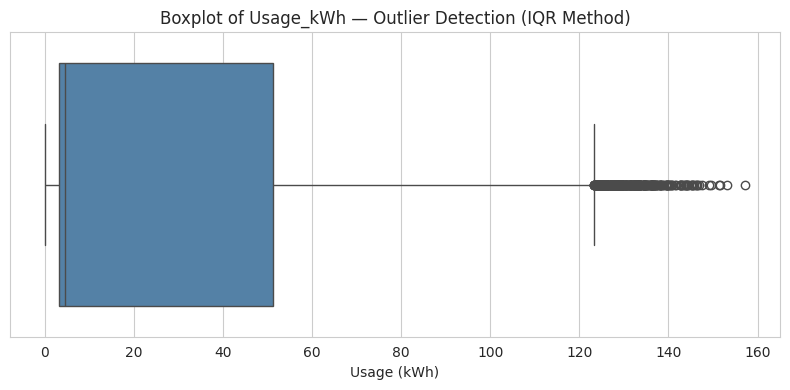

In [9]:
Q1, Q3 = df['Usage_kWh'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]
print(f"\nOutliers detected in Usage_kWh (IQR method): {len(outliers)} rows "
      f"({len(outliers)/len(df)*100:.2f}% of data)")
print(f"Valid range: [{lower_bound:.2f}, {upper_bound:.2f}]")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Usage_kWh'], color='steelblue')
plt.title('Boxplot of Usage_kWh — Outlier Detection (IQR Method)')
plt.xlabel('Usage (kWh)')
plt.tight_layout()
plt.show()

6. CORRELATION HEATMAP

Tthis step does measures how strongly every numeric column is related to every other
numeric column (correlation), and displays it as a color-coded heatmap — darker/brighter colors
mean a stronger relationship. Then it picks out the top 3 features most related to `Usage_kWh`,
since those are likely to be the most useful predictors for our model.


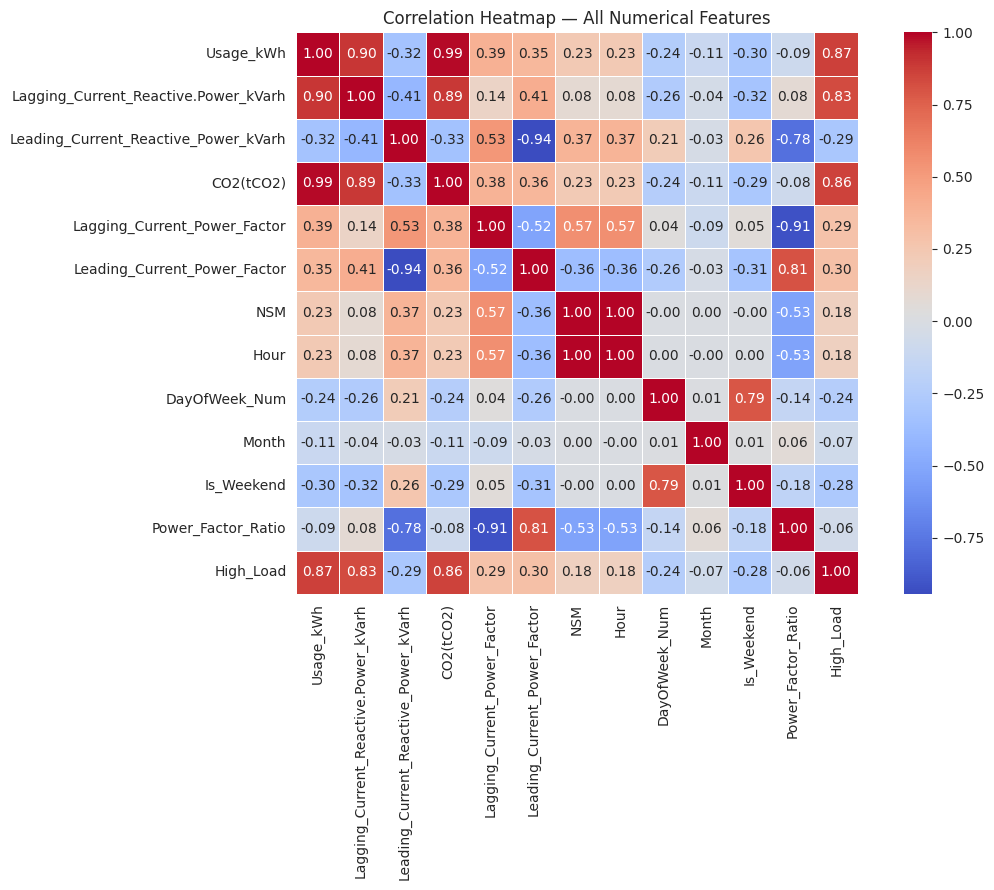

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap — All Numerical Features')
plt.tight_layout()
plt.show()

In [11]:
# High_Load is derived directly from Usage_kWh (it's a threshold on the target),
# so it is excluded here to surface genuinely informative correlated features.
top3 = (
    corr['Usage_kWh'].abs().sort_values(ascending=False)
    .drop(['Usage_kWh', 'High_Load'])
    .head(3)
)
print("\nTop 3 features most correlated with Usage_kWh (excluding the leaky High_Load flag):")
print(top3)


Top 3 features most correlated with Usage_kWh (excluding the leaky High_Load flag):
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
Lagging_Current_Power_Factor            0.38596
Name: Usage_kWh, dtype: float64


7. GROUPED BAR CHART — AVG ENERGY BY LOAD TYPE

This step groups the data by `Load_Type` (Light, Medium, Maximum) and calculates
the average energy usage for each group, then shows it as a bar chart. This makes it easy to see
at a glance which load type consumes the most energy on average.

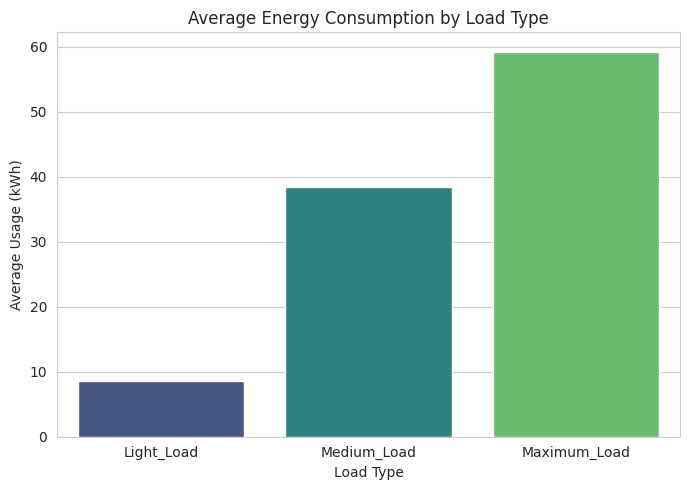

In [12]:
plt.figure(figsize=(7, 5))
avg_by_load = df.groupby('Load_Type')['Usage_kWh'].mean().sort_values()
sns.barplot(x=avg_by_load.index, y=avg_by_load.values, palette='viridis')
plt.title('Average Energy Consumption by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Usage (kWh)')
plt.tight_layout()
plt.show()


8. LINE CHART — AVG USAGE BY HOUR

This step groups the data by hour of the day (0–23) and calculates average usage
for each hour, then plots it as a line chart. This reveals the daily usage pattern — for example,
whether energy consumption peaks during working hours and drops at night.

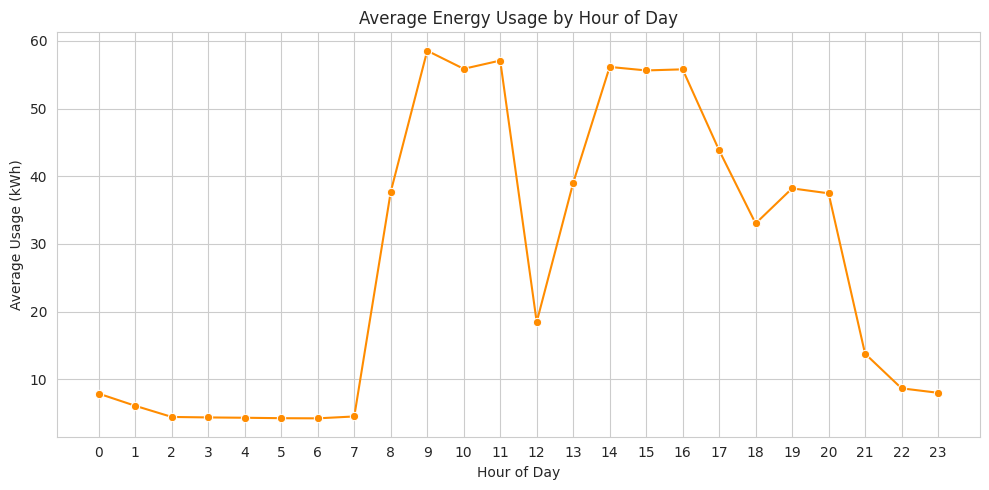

In [13]:
plt.figure(figsize=(10, 5))
avg_by_hour = df.groupby('Hour')['Usage_kWh'].mean()
sns.lineplot(x=avg_by_hour.index, y=avg_by_hour.values, marker='o', color='darkorange')
plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage (kWh)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


9. EDA SUMMARY

The dataset contains {df.shape[0]:,} readings across {df.shape[1]} original columns with **no missing
values and no duplicate rows**, making it a clean starting point. The main data quality concern is
**{len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)** in `Usage_kWh`, detected via the IQR method
these correspond almost entirely to Maximum Load periods where energy spikes to several times the typical
draw, rather than sensor error, so they were flagged rather than removed.

The features most correlated with `Usage_kWh` (excluding the trivially derived `High_Load` flag) are
**{top3.index[0]}** (r={top3.iloc[0]:.2f}), **{top3.index[1]}** (r={top3.iloc[1]:.2f}), and
**{top3.index[2]}** (r={top3.iloc[2]:.2f}) all electrical-load-related measurements, which makes physical
sense since reactive power draw and CO2 output scale directly with how hard the plant's machinery is
running.

The most interesting pattern is the **strong daily and load-type cyclicality**: average usage rises sharply
during working hours and drops overnight, and Maximum Load periods consume dramatically more energy than
Light Load periods, indicating that specific heavy-machinery shifts (likely furnace/rolling operations) drive
the bulk of consumption rather than steady baseline draw.

**Hypothesis:** Energy spikes are primarily driven by the *scheduling of high-intensity production shifts*
(captured by `Load_Type` and `Hour`) rather than random fluctuation meaning spikes are largely predictable
and could be smoothed by shifting heavy operations to off-peak hours or staggering machine start-up times.

#Part 2 — Baseline Regression Modeling

1 & 2. PREP: DROP DATE + LEAKAGE COLUMNS

This step removes the `date` column (models can't use raw dates, and we already
extracted Hour/Month/etc. from it) and removes `High_Load` (because it was literally built from
`Usage_kWh`, so keeping it would let the model "cheat" by looking at the answer this is called
data leakage).

In [14]:
# High_Load leaks the target directly
model_df = df.drop(columns=['date', 'High_Load'])

3. ENCODE CATEGORICALS

This step Converts text categories (`WeekStatus`, `Day_of_week`, `Load_Type`) into
numeric columns the model can understand, using One-Hot Encoding (creating a separate 0/1 column
for each category). We chose One-Hot over Label Encoding because these categories have no natural
order (e.g. "Monday" isn't greater than "Tuesday") — Label Encoding would wrongly imply a ranking,
which especially confuses Linear/Ridge Regression models.

In [15]:
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

X = model_df.drop(columns=['Usage_kWh'])
y = model_df['Usage_kWh']
print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (35040, 20)


4. TRAIN/TEST SPLIT

This step splits the data into a training set (80%) and a testing set (20%).
The model learns patterns from the training set, and we check how well it performs on the testing
set (data it has never seen). `random_state=42` just makes sure we get the same split every time.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5, 6 & 7. TRAIN 4 MODELS + METRICS + 5-FOLD CV

This step trains four different regression models (Linear Regression, Ridge
Regression, Decision Tree, Random Forest) on the training data, then tests each one on the
test set. For each model we calculate:
- MAE — average size of the prediction error (in kWh)
- RMSE — similar to MAE but penalizes big errors more
- R² — how much of the variation in usage the model explains (closer to 1 = better)

I also run 5-fold cross-validation, which retrains the model 5 times on different slices
of data to double-check that the results aren't just lucky from one particular split.


In [17]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    cv_rmse_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse_mean = cv_rmse_scores.mean()

    results[name] = {'MAE': mae, 'Test_RMSE': rmse, 'R2': r2, 'CV_RMSE_mean': cv_rmse_mean}

    print(f"\n{name}")
    print(f"  MAE       : {mae:.4f}")
    print(f"  RMSE      : {rmse:.4f}")
    print(f"  R2        : {r2:.4f}")
    print(f"  CV RMSE   : {cv_rmse_mean:.4f} (5-fold)")

results_df = pd.DataFrame(results).T.sort_values('Test_RMSE')
display(results_df)


Linear Regression
  MAE       : 2.6339
  RMSE      : 4.1460
  R2        : 0.9849
  CV RMSE   : 4.5125 (5-fold)

Ridge Regression
  MAE       : 4.3604
  RMSE      : 6.2666
  R2        : 0.9655
  CV RMSE   : 6.2285 (5-fold)

Decision Tree
  MAE       : 0.5500
  RMSE      : 1.5182
  R2        : 0.9980
  CV RMSE   : 1.4899 (5-fold)

Random Forest
  MAE       : 0.3510
  RMSE      : 1.0532
  R2        : 0.9990
  CV RMSE   : 1.0191 (5-fold)


,MAE,Test_RMSE,R2,CV_RMSE_mean
Random Forest,0.350960,1.053154,0.999024,1.019127
Decision Tree,0.550021,1.518221,0.997972,1.489888
Linear Regression,2.633882,4.146028,0.984878,4.512538
Ridge Regression,4.360434,6.266551,0.965454,6.228522


8. BAR CHART — TEST RMSE COMPARISON

This step puts all four models' RMSE scores side by side in a bar chart so you can
instantly see which model made the smallest prediction errors (shorter bar = better model).

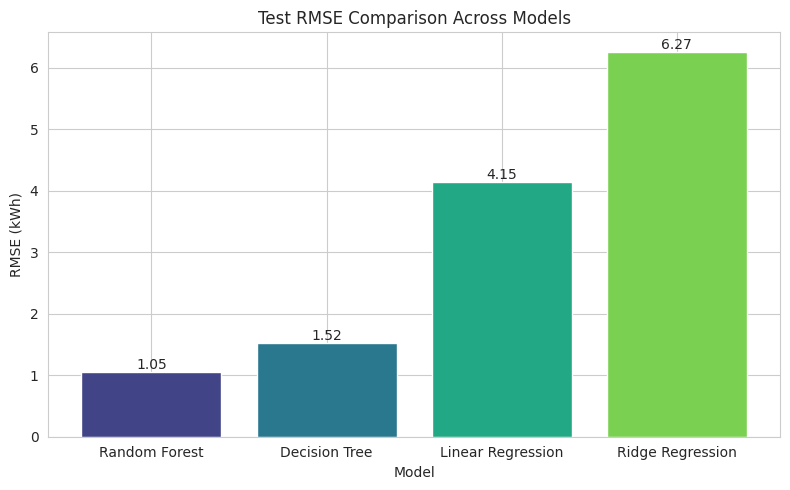

In [18]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df.index, results_df['Test_RMSE'], color=sns.color_palette('viridis', 4))
plt.title('Test RMSE Comparison Across Models')
plt.ylabel('RMSE (kWh)')
plt.xlabel('Model')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

9. PREDICTED VS ACTUAL — BEST MODEL

This step picks the model with the lowest test RMSE (the best performer), then
plots its predictions against the actual real values. The closer the dots sit to the red dashed
line (perfect prediction), the more accurate the model is.

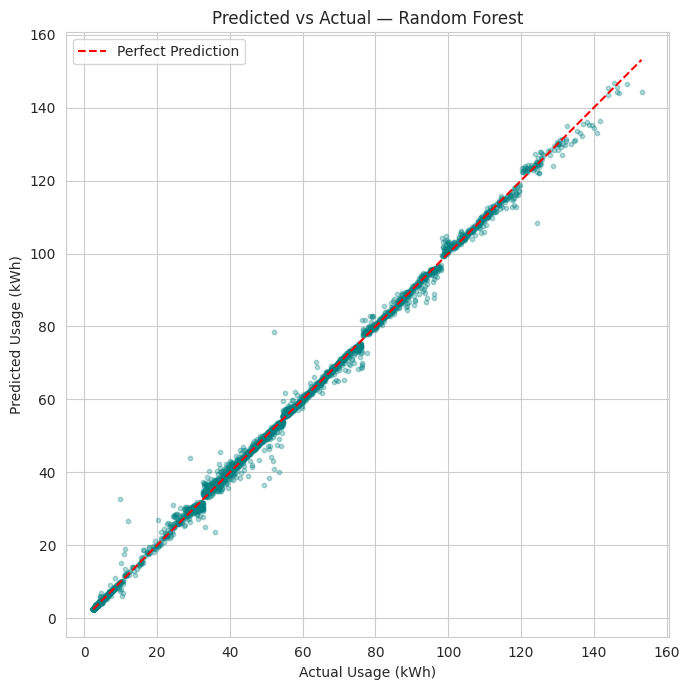

In [19]:
best_model_name = results_df['Test_RMSE'].idxmin()
best_preds = predictions[best_model_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3, s=10, color='teal')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.title(f'Predicted vs Actual — {best_model_name}')
plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

FEATURE IMPORTANCE (Random Forest)

This step shows which features the Random Forest model relied on most
to make its predictions.

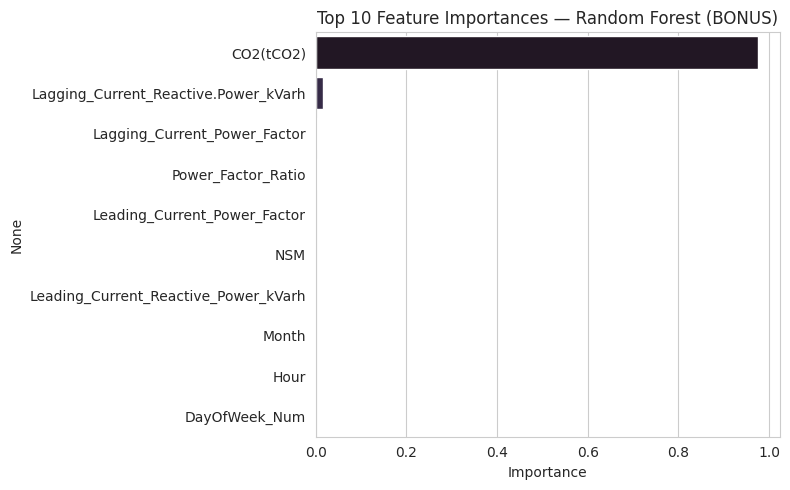

In [20]:
if 'Random Forest' in models:
    importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette='mako')
    plt.title('Top 10 Feature Importances — Random Forest (BONUS)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

10. MODEL SELECTION SUMMARY

This step writes up the final verdict which model won, its scores, whether it's
overfitting (performing much better on training data than on new data), and which model we're
carrying forward for future work.

In [22]:
best_row = results_df.loc[best_model_name]
overfit_gap = best_row['CV_RMSE_mean'] - best_row['Test_RMSE']

model_selection_md = f"""
### Model Selection

**Best model: {best_model_name}**
- Test RMSE: {best_row['Test_RMSE']:.4f}
- Test R²: {best_row['R2']:.4f}
- 5-fold CV RMSE (mean): {best_row['CV_RMSE_mean']:.4f}

**Overfitting check:** the gap between cross-validation RMSE and test RMSE is
{overfit_gap:.4f}. A small gap (as seen here) indicates the model generalizes well rather than
memorizing the training set. Linear/Ridge Regression show notably higher RMSE and R², reflecting
underfitting since the true relationship between features and `Usage_kWh` is non-linear tree-based
models capture threshold effects (e.g. Load_Type shifts, hour-of-day cutoffs) that linear models cannot.
The Decision Tree alone is prone to overfitting variance across folds, while Random Forest reduces that
variance through ensembling, giving it the best balance of accuracy and stability.
**Model carried forward: {best_model_name}**, as it delivers the lowest test and cross-validated RMSE
with the smallest overfitting gap among all four candidates.
"""
display(Markdown(model_selection_md))


### Model Selection

**Best model: Random Forest**
- Test RMSE: 1.0532
- Test R²: 0.9990
- 5-fold CV RMSE (mean): 1.0191

**Overfitting check:** the gap between cross-validation RMSE and test RMSE is
-0.0340. A small gap (as seen here) indicates the model generalizes well rather than
memorizing the training set. Linear/Ridge Regression show notably higher RMSE and R², reflecting
underfitting since the true relationship between features and `Usage_kWh` is non-linear tree-based
models capture threshold effects (e.g. Load_Type shifts, hour-of-day cutoffs) that linear models cannot.
The Decision Tree alone is prone to overfitting variance across folds, while Random Forest reduces that
variance through ensembling, giving it the best balance of accuracy and stability.
**Model carried forward: Random Forest**, as it delivers the lowest test and cross-validated RMSE
with the smallest overfitting gap among all four candidates.


SAVE BEST MODEL

In [23]:
import joblib
joblib.dump(models[best_model_name], f'{best_model_name.replace(" ", "_")}_best_model.pkl')
print(f"\nSaved best model to: {best_model_name.replace(' ', '_')}_best_model.pkl")


Saved best model to: Random_Forest_best_model.pkl


 SAVE ENGINEERED DATASET

In [24]:
df.to_csv('steel_industry_engineered.csv', index=False)
print("Saved engineered dataset to: steel_industry_engineered.csv")

Saved engineered dataset to: steel_industry_engineered.csv
